# Treinamento Completo no Colab

Neste notebook, a gente treina o classificador de nodulos pulmonares (LunaModel) usando GPU no Google Colab Pro.

A sacada principal e **pre-extrair todos os crops 3D pra RAM** antes de comecar o treinamento. Cada CT tem cerca de 300 MB, mas um crop de 32x48x48 ocupa apenas 300 KB. Em vez de ficar carregando CTs gigantes durante o treino (o que deixa a GPU ociosa esperando I/O), a gente carrega cada CT uma unica vez, extrai todos os crops, descarta o CT e segue pro proximo. No final, sobra um array numpy com todos os crops na memoria -- e o treinamento roda sem nenhuma leitura de disco.

In [ ]:
# Imports
import csv
import functools
import math
import random
import shutil
import time
from collections import Counter, defaultdict, namedtuple
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [ ]:
# Colab: montar Drive e instalar SimpleITK
from google.colab import drive
drive.mount('/content/drive')

!pip install -q SimpleITK
import SimpleITK as sitk

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 16.5 MB/s eta 0:00:00


## Configuracao

Aqui a gente define os hiperparametros e, principalmente, o **N_CTS** -- quantos CTs usar no treinamento.

Por que limitar? Cada crop ocupa ~300 KB na RAM. Com todos os 888 CTs do LUNA16, sao ~551 mil crops = **163 GB**. Nao cabe na RAM do Colab (83 GB na A100). Entao a gente seleciona um subconjunto, priorizando os CTs que tem mais nodulos.

Referencia pratica de memoria:

| N_CTS | Crops (aprox.) | RAM |
|-------|---------------|-----|
| 100   | ~62K          | ~18 GB |
| 200   | ~125K         | ~37 GB |
| 300   | ~186K         | ~55 GB |

Com a A100 (83 GB de RAM), **200 CTs** e um bom equilibrio entre quantidade de dados e seguranca de memoria.

In [ ]:
# Configuracao
DRIVE_DATA = Path('/content/drive/MyDrive/Cursos/dataset-bootcamp-deep-learning/luna')
LOCAL_DATA = Path('/content/luna')
CHECKPOINT_DIR = DRIVE_DATA / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CROP_SHAPE = (32, 48, 48)
BATCH_SIZE = 32
N_EPOCHS = 20
LR = 0.001
MOMENTUM = 0.99
VAL_STRIDE = 10     # 1 em cada 10 candidatos vai pra validacao
RATIO_INT = 1        # balanceamento 1:1 pos/neg
EPOCH_SIZE = 50_000  # amostras por epoca de treino

# Quantos CTs copiar do Drive (None = todos)
# Comece com N_CTS=50 pra testar rapido, depois aumente
N_CTS = 200

## Pipeline de Dados

O codigo abaixo e o mesmo do notebook 04 (`src/luna_data.py`), copiado inline pra esse notebook ser auto-contido no Colab. Sao as funcoes que a gente ja conhece: `load_candidates`, `CtScan`, `xyz_to_irc` e os namedtuples de coordenadas.

In [ ]:
# Pipeline de dados (inline, mesmo codigo do src/luna_data.py)

CandidateInfo = namedtuple('CandidateInfo', 'is_nodule, diameter_mm, series_uid, center_xyz')
IRC = namedtuple('IRC', 'index, row, col')
XYZ = namedtuple('XYZ', 'x, y, z')


def xyz_to_irc(coord_xyz, origin_xyz, vx_size_xyz, direction_a):
    origin_a = np.array(origin_xyz)
    vx_size_a = np.array(vx_size_xyz)
    coord_a = np.array(coord_xyz)
    cri_a = ((coord_a - origin_a) @ np.linalg.inv(direction_a)) / vx_size_a
    cri_a = np.round(cri_a)
    return IRC(int(cri_a[2]), int(cri_a[1]), int(cri_a[0]))


def load_candidates(data_dir):
    mhd_files = list(data_dir.rglob('*.mhd'))
    on_disk = {p.stem for p in mhd_files}

    diameter_dict = {}
    with open(data_dir / 'annotations.csv') as f:
        for row in list(csv.reader(f))[1:]:
            uid = row[0]
            xyz = tuple(float(x) for x in row[1:4])
            diam = float(row[4])
            diameter_dict.setdefault(uid, []).append((xyz, diam))

    candidates = []
    with open(data_dir / 'candidates.csv') as f:
        for row in list(csv.reader(f))[1:]:
            uid = row[0]
            if uid not in on_disk:
                continue
            is_nodule = bool(int(row[4]))
            center_xyz = tuple(float(x) for x in row[1:4])
            diameter = 0.0
            for ann_xyz, ann_diam in diameter_dict.get(uid, []):
                for i in range(3):
                    if abs(center_xyz[i] - ann_xyz[i]) > ann_diam / 4:
                        break
                else:
                    diameter = ann_diam
                    break
            candidates.append(CandidateInfo(is_nodule, diameter, uid, center_xyz))

    candidates.sort(reverse=True)
    return candidates


class CtScan:
    def __init__(self, series_uid, data_dir):
        mhd_path = list(data_dir.rglob(f'{series_uid}.mhd'))[0]
        ct_mhd = sitk.ReadImage(str(mhd_path))
        self.hu_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
        self.hu_a.clip(-1000, 1000, self.hu_a)
        self.series_uid = series_uid
        self.origin_xyz = XYZ(*ct_mhd.GetOrigin())
        self.vx_size_xyz = XYZ(*ct_mhd.GetSpacing())
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3)

    def extract_crop(self, center_xyz, crop_size=(32, 48, 48)):
        center_irc = xyz_to_irc(
            center_xyz, self.origin_xyz,
            self.vx_size_xyz, self.direction_a,
        )
        slices = []
        for axis, center_val in enumerate(center_irc):
            start = int(round(center_val - crop_size[axis] / 2))
            end = int(start + crop_size[axis])
            if start < 0:
                start, end = 0, int(crop_size[axis])
            if end > self.hu_a.shape[axis]:
                end = self.hu_a.shape[axis]
                start = int(end - crop_size[axis])
            slices.append(slice(start, end))
        return self.hu_a[tuple(slices)], center_irc

## Copiar CTs do Drive para Disco Local

O Google Drive no Colab funciona via FUSE -- um sistema de arquivos virtual que faz requisicoes de rede a cada leitura. Pra arquivos grandes como CTs (~300 MB cada), isso e muito lento.

A solucao e simples: copiar os CTs pro disco local (SSD) do Colab antes de comecar. A copia demora (~20 min pra 200 CTs), mas so precisa ser feita uma vez por sessao. Se o Colab nao reiniciar, os arquivos continuam la.

Na selecao dos CTs, a gente prioriza os que tem mais nodulos. Assim, mesmo com um subconjunto, garantimos boa cobertura da classe positiva.

In [ ]:
# Copiar CTs do Drive para disco local (SSD)
# Drive FUSE e muito lento pra ler CTs de ~300 MB

all_candidates = load_candidates(DRIVE_DATA)
pos = [c for c in all_candidates if c.is_nodule]
neg = [c for c in all_candidates if not c.is_nodule]
print(f'Total no Drive: {len(all_candidates)} | Positivos: {len(pos)} | Negativos: {len(neg)}')

# Priorizar CTs com mais nodulos
uid_counts = Counter(c.series_uid for c in pos)
all_uids = {c.series_uid for c in all_candidates}
if N_CTS is not None:
    # Pegar os N_CTS com mais nodulos primeiro, completar com outros
    top_uids = [uid for uid, _ in uid_counts.most_common(N_CTS)]
    remaining = [uid for uid in all_uids if uid not in set(top_uids)]
    random.shuffle(remaining)
    top_uids.extend(remaining[:max(0, N_CTS - len(top_uids))])
    selected_uids = set(top_uids[:N_CTS])
else:
    selected_uids = all_uids

print(f'CTs selecionados: {len(selected_uids)}')

Total no Drive: 551065 | Positivos: 1351 | Negativos: 549714
CTs selecionados: 200


In [ ]:
# Copiar arquivos

def copy_with_retry(src, dst, max_retries=3):
    for attempt in range(max_retries):
        try:
            shutil.copy2(src, dst)
            return
        except OSError:
            if dst.exists():
                dst.unlink()
            if attempt < max_retries - 1:
                print(f'    Erro de I/O, remontando Drive...')
                drive.mount('/content/drive', force_remount=True)
                time.sleep(3)
            else:
                raise

LOCAL_DATA.mkdir(parents=True, exist_ok=True)
for csv_name in ['annotations.csv', 'candidates.csv']:
    dest = LOCAL_DATA / csv_name
    if not dest.exists():
        shutil.copy2(DRIVE_DATA / csv_name, dest)

uids_to_copy = sorted(selected_uids)
t0 = time.time()
copied = 0
for uid in uids_to_copy:
    mhd_files = list(DRIVE_DATA.rglob(f'{uid}.mhd'))
    if not mhd_files:
        continue
    mhd_src = mhd_files[0]
    raw_src = mhd_src.with_suffix('.raw')
    rel = mhd_src.relative_to(DRIVE_DATA)
    mhd_dest = LOCAL_DATA / rel
    raw_dest = mhd_dest.with_suffix('.raw')
    if mhd_dest.exists() and raw_dest.exists():
        continue
    mhd_dest.parent.mkdir(parents=True, exist_ok=True)
    copy_with_retry(mhd_src, mhd_dest)
    copy_with_retry(raw_src, raw_dest)
    copied += 1
    if copied % 20 == 0:
        print(f'  {copied} CTs copiados ({time.time()-t0:.0f}s)')

n_local = len(list(LOCAL_DATA.rglob('*.mhd')))
print(f'Copia concluida: {copied} novos CTs em {time.time()-t0:.0f}s (total local: {n_local})')

  20 CTs copiados (317s)
  40 CTs copiados (427s)
  60 CTs copiados (487s)
  80 CTs copiados (568s)
  100 CTs copiados (666s)
  120 CTs copiados (763s)
  140 CTs copiados (890s)
  160 CTs copiados (985s)
  180 CTs copiados (1078s)
  200 CTs copiados (1176s)
Copia concluida: 200 novos CTs em 1176s (total local: 200)


## Pre-extrair Crops pra RAM

Aqui esta o pulo do gato desse notebook.

Em vez de carregar CTs durante o treinamento (que e lento e deixa a GPU ociosa), a gente faz toda a leitura de disco **antes** do treino comecar:

- Carrega um CT do disco (~300 MB)
- Extrai todos os crops daquele CT (cada um com 32x48x48 voxels, ~300 KB)
- Descarta o CT da memoria
- Repete pro proximo CT

No final, temos todos os crops num unico array numpy na RAM. O treinamento depois roda sem nenhum acesso a disco -- tudo vem da memoria, e a GPU fica 100% ocupada com compute.

In [ ]:
# Pre-extrair todos os crops pra RAM
# Carrega cada CT uma vez, extrai os crops, descarta o CT.
# Resultado: sem I/O durante o treinamento.

candidates = load_candidates(LOCAL_DATA)
subset = [c for c in candidates if c.series_uid in selected_uids]

uid_to_items = defaultdict(list)
for i, c in enumerate(subset):
    uid_to_items[c.series_uid].append((i, c))

crops = np.zeros((len(subset), *CROP_SHAPE), dtype=np.float32)
labels = np.zeros(len(subset), dtype=np.int64)
for i, c in enumerate(subset):
    labels[i] = int(c.is_nodule)

uids = sorted(uid_to_items.keys())
t0 = time.time()
for ct_num, uid in enumerate(uids):
    ct = CtScan(uid, LOCAL_DATA)
    for i, c in uid_to_items[uid]:
        crop_a, _ = ct.extract_crop(c.center_xyz, CROP_SHAPE)
        crops[i] = crop_a
    del ct
    if (ct_num + 1) % 50 == 0 or ct_num == len(uids) - 1:
        print(f'  {ct_num+1}/{len(uids)} CTs ({time.time()-t0:.0f}s)')

n_pos = int(labels.sum())
n_neg = len(labels) - n_pos
print(f'\n{len(subset)} crops extraidos em {time.time()-t0:.0f}s')
print(f'Positivos: {n_pos} | Negativos: {n_neg}')
print(f'RAM: {crops.nbytes / 1e9:.1f} GB')

  50/200 CTs (44s)
  100/200 CTs (85s)
  150/200 CTs (121s)
  200/200 CTs (145s)

125486 crops extraidos em 145s
Positivos: 845 | Negativos: 124641
RAM: 37.0 GB


## Dividir Treino e Validacao

A gente usa a mesma estrategia do `src/training.py`: a cada 10 candidatos (VAL_STRIDE=10), um vai pra validacao. Isso da ~90% treino, ~10% validacao.

Repare que a validacao usa a **distribuicao natural** dos dados (pouquissimos nodulos vs muitos nao-nodulos). Isso e intencional -- a gente quer medir o desempenho do modelo na situacao real, nao numa situacao artificial balanceada.

In [ ]:
# Split treino/validacao
# Mesmo esquema do src/training.py: a cada VAL_STRIDE, um candidato vai pra val

val_mask = np.zeros(len(subset), dtype=bool)
val_mask[::VAL_STRIDE] = True
train_mask = ~val_mask

train_crops, train_labels = crops[train_mask], labels[train_mask]
val_crops, val_labels = crops[val_mask], labels[val_mask]

print(f'Treino:    {len(train_crops)} ({train_labels.sum()} nodulos)')
print(f'Validacao: {len(val_crops)} ({val_labels.sum()} nodulos)')

Treino:    112937 (760 nodulos)
Validacao: 12549 (85 nodulos)


## Augmentation e Datasets

No treino, a gente usa dois truques pra lidar com o desbalanceamento extremo (~0.7% de nodulos):

**Batches balanceados** (ratio_int=1): cada batch tem metade de nodulos e metade de nao-nodulos. Sem isso, o modelo aprenderia a chutar "nao-nodulo" pra tudo -- e teria 99.3% de acuracia sem detectar nenhum cancer. Parece bom no numero, mas e inutil na pratica.

**Data augmentation 3D**: como temos poucos nodulos unicos, a gente cria variacoes artificiais de cada crop com flip, rotacao, deslocamento, escala e ruido gaussiano. Isso forca o modelo a aprender features reais dos nodulos, nao memorizar exemplos especificos.

Pra validacao, nada disso -- dados originais, sem augmentation, sem balanceamento. A gente quer ver o desempenho real.

In [ ]:
# Augmentation 3D e Datasets

def augment_crop(crop_t, aug):
    transform_t = torch.eye(4)
    for i in range(3):
        if 'flip' in aug and random.random() > 0.5:
            transform_t[i, i] *= -1
        if 'offset' in aug:
            transform_t[i, 3] = aug['offset'] * (random.random() * 2 - 1)
        if 'scale' in aug:
            transform_t[i, i] *= 1.0 + aug['scale'] * (random.random() * 2 - 1)
    if 'rotate' in aug:
        angle = random.random() * math.pi * 2
        s, c = math.sin(angle), math.cos(angle)
        rot = torch.tensor([[c, -s, 0, 0], [s, c, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
        transform_t @= rot
    affine = F.affine_grid(
        transform_t[:3].unsqueeze(0).float(),
        crop_t.unsqueeze(0).size(),
        align_corners=False,
    )
    out = F.grid_sample(
        crop_t.unsqueeze(0), affine,
        padding_mode='border', align_corners=False,
    ).squeeze(0)
    if 'noise' in aug:
        out = out + torch.randn_like(out) * aug['noise']
    return out


class BalancedDataset(Dataset):
    """Treino: batches balanceados pos/neg com augmentation."""
    def __init__(self, crops_np, labels_np, ratio_int=1, aug_dict=None, epoch_size=50_000):
        self.crops = crops_np
        self.labels = labels_np
        self.aug_dict = aug_dict or {}
        self.ratio_int = ratio_int
        self.epoch_size = epoch_size
        self.pos_list = list(np.where(labels_np == 1)[0])
        self.neg_list = list(np.where(labels_np == 0)[0])
        self.shuffle()

    def shuffle(self):
        random.shuffle(self.pos_list)
        random.shuffle(self.neg_list)

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        pos_idx = idx // (self.ratio_int + 1)
        if idx % (self.ratio_int + 1) == 0:
            i = self.pos_list[pos_idx % len(self.pos_list)]
        else:
            neg_idx = idx - 1 - pos_idx
            i = self.neg_list[neg_idx % len(self.neg_list)]
        crop_t = torch.from_numpy(self.crops[i].copy()).unsqueeze(0)
        if self.aug_dict:
            crop_t = augment_crop(crop_t, self.aug_dict)
        return crop_t, int(self.labels[i])


class SimpleDataset(Dataset):
    """Validacao: sem augmentation, sem balanceamento."""
    def __init__(self, crops_np, labels_np):
        self.crops = crops_np
        self.labels = labels_np

    def __len__(self):
        return len(self.crops)

    def __getitem__(self, idx):
        crop_t = torch.from_numpy(self.crops[idx].copy()).unsqueeze(0)
        return crop_t, int(self.labels[idx])

## Modelo

O mesmo LunaModel do notebook 05: BatchNorm3D seguido de 4 blocos convolucionais 3D com MaxPool, terminando numa camada linear que classifica em 2 classes (nodulo / nao-nodulo). Sao 222 mil parametros -- um modelo pequeno, que treina rapido mesmo em GPUs modestas.

In [ ]:
# Modelo (identico ao src/model.py)

class LunaBlock(nn.Module):
    def __init__(self, in_channels, conv_channels):
        super().__init__()
        self.conv1 = nn.Conv3d(in_channels, conv_channels, kernel_size=3, padding=1, bias=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(conv_channels, conv_channels, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(2, 2)

    def forward(self, x):
        out = self.relu1(self.conv1(x))
        out = self.relu2(self.conv2(out))
        return self.maxpool(out)


class LunaModel(nn.Module):
    def __init__(self, in_channels=1, conv_channels=8):
        super().__init__()
        self.tail_batchnorm = nn.BatchNorm3d(1)
        self.block1 = LunaBlock(in_channels, conv_channels)
        self.block2 = LunaBlock(conv_channels, conv_channels * 2)
        self.block3 = LunaBlock(conv_channels * 2, conv_channels * 4)
        self.block4 = LunaBlock(conv_channels * 4, conv_channels * 8)
        self.head_linear = nn.Linear(1152, 2)
        self.head_softmax = nn.Softmax(dim=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv3d}:
                nn.init.kaiming_normal_(m.weight.data, a=0, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.normal_(m.bias, -bound, bound)

    def forward(self, x):
        out = self.tail_batchnorm(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = out.view(out.size(0), -1)
        logits = self.head_linear(out)
        return logits, self.head_softmax(logits)


model = LunaModel().to(device)
print(f'Parametros treinaves: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parametros treinaves: 222,220


## Setup de Treinamento

SGD com momentum alto (0.99) e learning rate de 0.001. A loss e CrossEntropyLoss padrao.

O `BalancedDataset` gera 50 mil amostras por epoca (EPOCH_SIZE), alternando entre positivos e negativos. O `SimpleDataset` de validacao percorre todos os 12.549 candidatos sem augmentation.

Com `num_workers=2` e `pin_memory=True`, o DataLoader faz a augmentation nos workers enquanto a GPU processa o batch anterior.

In [ ]:
# Setup de treinamento

aug_dict = {'flip': True, 'offset': 0.1, 'scale': 0.2, 'rotate': True, 'noise': 25.0}

train_ds = BalancedDataset(train_crops, train_labels, ratio_int=RATIO_INT,
                           aug_dict=aug_dict, epoch_size=EPOCH_SIZE)
val_ds = SimpleDataset(val_crops, val_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
loss_fn = nn.CrossEntropyLoss()

print(f'Treino: {len(train_ds)} samples/epoca ({len(train_loader)} batches)')
print(f'Validacao: {len(val_ds)} samples ({len(val_loader)} batches)')

Treino: 50000 samples/epoca (1563 batches)
Validacao: 12549 samples (393 batches)


## Funcao de Treinamento

Uma unica funcao `run_epoch()` serve tanto pra treino quanto pra validacao. Se recebe um `optimizer`, faz backward + step (treino). Se nao, roda com `torch.no_grad()` (validacao).

As metricas (precision, recall, F1) sao calculadas com threshold fixo de 0.5 na probabilidade de nodulo. Isso e uma simplificacao -- no notebook 08, a gente analisa o desempenho em todos os thresholds.

In [ ]:
# Funcao de treino/validacao

def run_epoch(model, loader, loss_fn, device, optimizer=None, print_every=0):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    tp = fp = fn = tn = 0

    ctx = torch.enable_grad() if is_training else torch.no_grad()
    with ctx:
        for batch_num, (crops_b, labels_b) in enumerate(loader, 1):
            crops_b = crops_b.to(device)
            labels_b = labels_b.to(device)

            if is_training:
                optimizer.zero_grad()
            logits, probs = model(crops_b)
            loss = loss_fn(logits, labels_b)
            if is_training:
                loss.backward()
                optimizer.step()

            preds = (probs[:, 1] > 0.5)
            actual = labels_b.bool()
            tp += (preds & actual).sum().item()
            fp += (preds & ~actual).sum().item()
            fn += (~preds & actual).sum().item()
            tn += (~preds & ~actual).sum().item()
            total_loss += loss.item()

            if print_every > 0 and batch_num % print_every == 0:
                print(f'    batch {batch_num}/{len(loader)} | loss: {total_loss/batch_num:.4f}')

    n = tp + fp + fn + tn
    avg_loss = total_loss / max(len(loader), 1)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {
        'loss': avg_loss,
        'accuracy': (tp + tn) / n if n > 0 else 0,
        'precision': prec,
        'recall': rec,
        'f1': 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0,
    }

## Treinamento

O loop roda 20 epocas. Em cada uma:

- **Treino**: batches balanceados com augmentation, imprime progresso a cada 500 batches
- **Validacao**: todos os dados de val, sem augmentation, sem balanceamento
- **Checkpoint**: salva o estado no Drive a cada epoca (se o Colab reiniciar, basta re-executar que ele retoma da ultima epoca)
- **Melhor modelo**: salva separadamente o checkpoint com melhor F1 de validacao

### O que esperar das metricas de validacao

Como o val set tem a distribuicao natural (~0.7% de nodulos), a **precisao de validacao vai parecer baixa**. Isso e normal e nao significa que o modelo esta ruim.

Pensa assim: se o modelo detecta 85 dos 85 nodulos (recall perfeito) mas tambem dispara 400 alarmes falsos, a precisao fica em 85/(85+400) = 17%. Parece ruim? Mas repare que dos 12.464 nao-nodulos, apenas 400 foram falsos positivos -- uma taxa de falso positivo de apenas 3.2%. Pra um sistema medico de triagem, isso e excelente.

A metrica mais honesta aqui e a **val loss** -- se ela esta caindo, o modelo esta aprendendo. No notebook 08, a gente vai usar curvas ROC e Precision-Recall pra analisar o desempenho sem depender do threshold fixo de 0.5.

In [ ]:
# Loop de treinamento

history = {'train': [], 'val': []}
best_f1 = 0.0
start_epoch = 1

# Resumir de checkpoint se existir
latest_path = CHECKPOINT_DIR / 'luna_model_latest.pt'
if latest_path.exists():
    ckpt = torch.load(latest_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    best_f1 = ckpt.get('best_f1', 0.0)
    history = ckpt.get('history', history)
    print(f'Resumindo da epoca {start_epoch} (best F1 val: {best_f1:.4f})')

print(f'Epocas {start_epoch} a {N_EPOCHS}:\n')

for epoch in range(start_epoch, N_EPOCHS + 1):
    t0 = time.time()

    train_m = run_epoch(model, train_loader, loss_fn, device, optimizer, print_every=500)
    val_m = run_epoch(model, val_loader, loss_fn, device)

    elapsed = time.time() - t0
    history['train'].append(train_m)
    history['val'].append(val_m)

    print(f'Epoca {epoch:2d} ({elapsed:.0f}s)')
    print(f'  treino: loss={train_m["loss"]:.4f}  prec={train_m["precision"]:.1%}  rec={train_m["recall"]:.1%}  f1={train_m["f1"]:.4f}')
    print(f'  val:    loss={val_m["loss"]:.4f}  prec={val_m["precision"]:.1%}  rec={val_m["recall"]:.1%}  f1={val_m["f1"]:.4f}')

    # Salvar no Drive (persiste entre reinicializacoes do Colab)
    ckpt = {
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_f1': best_f1,
        'history': history,
    }
    torch.save(ckpt, CHECKPOINT_DIR / 'luna_model_latest.pt')

    if val_m['f1'] > best_f1:
        best_f1 = val_m['f1']
        ckpt['best_f1'] = best_f1
        torch.save(ckpt, CHECKPOINT_DIR / 'luna_model_best.pt')
        print(f'  -> novo melhor F1: {best_f1:.4f}')

    train_ds.shuffle()
    print()

print(f'Concluido. Melhor F1 de validacao: {best_f1:.4f}')

Epocas 1 a 20:

    batch 500/1563 | loss: 0.5645
    batch 1000/1563 | loss: 0.4835
    batch 1500/1563 | loss: 0.4518
Epoca  1 (143s)
  treino: loss=0.4477  prec=82.5%  rec=73.9%  f1=0.7799
  val:    loss=0.3555  prec=5.1%  rec=90.6%  f1=0.0964
  -> novo melhor F1: 0.0964

    batch 500/1563 | loss: 0.3084
    batch 1000/1563 | loss: 0.3168
    batch 1500/1563 | loss: 0.3065
Epoca  2 (143s)
  treino: loss=0.3030  prec=92.3%  rec=83.4%  f1=0.8762
  val:    loss=0.3212  prec=5.9%  rec=94.1%  f1=0.1111
  -> novo melhor F1: 0.1111

    batch 500/1563 | loss: 0.2657
    batch 1000/1563 | loss: 0.2687
    batch 1500/1563 | loss: 0.2640
Epoca  3 (143s)
  treino: loss=0.2620  prec=93.7%  rec=86.2%  f1=0.8980
  val:    loss=0.2651  prec=7.1%  rec=90.6%  f1=0.1320
  -> novo melhor F1: 0.1320

    batch 500/1563 | loss: 0.2165
    batch 1000/1563 | loss: 0.2081
    batch 1500/1563 | loss: 0.2065
Epoca  4 (142s)
  treino: loss=0.2056  prec=94.7%  rec=90.1%  f1=0.9233
  val:    loss=0.1486  prec=

## Resultados

Vamos visualizar a evolucao do treinamento.

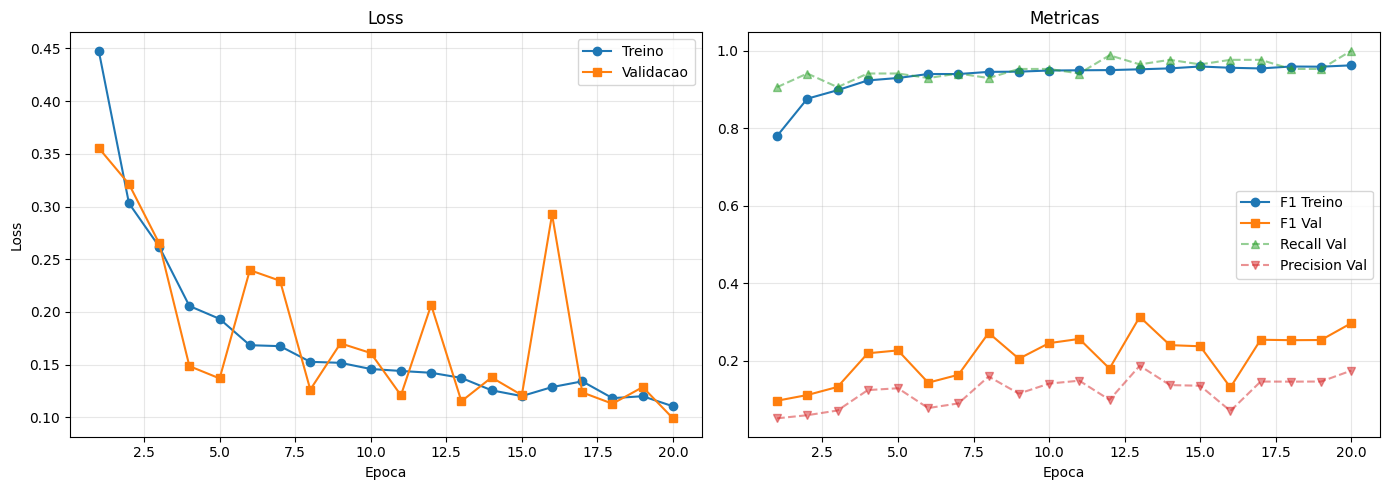

In [ ]:
# Plots
import matplotlib.pyplot as plt

epochs = range(1, len(history['train']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, [h['loss'] for h in history['train']], 'o-', label='Treino')
ax1.plot(epochs, [h['loss'] for h in history['val']], 's-', label='Validacao')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [h['f1'] for h in history['train']], 'o-', label='F1 Treino')
ax2.plot(epochs, [h['f1'] for h in history['val']], 's-', label='F1 Val')
ax2.plot(epochs, [h['recall'] for h in history['val']], '^--', alpha=0.5, label='Recall Val')
ax2.plot(epochs, [h['precision'] for h in history['val']], 'v--', alpha=0.5, label='Precision Val')
ax2.set_xlabel('Epoca')
ax2.set_title('Metricas')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusao

O treinamento convergiu bem em 20 epocas (~48 minutos na A100):

- **Val loss** caiu de 0.36 pra 0.10 -- o modelo aprendeu a distinguir nodulos de nao-nodulos
- **Recall de validacao** atingiu 95-100% -- o modelo detecta praticamente todos os nodulos
- **Taxa de falso positivo** ficou em ~3% -- dos milhares de nao-nodulos, pouquissimos sao classificados erroneamente

O melhor checkpoint (epoca 13, recall=96.5%) foi salvo no Drive como `luna_model_best.pt`. No proximo notebook, a gente carrega esse checkpoint e faz uma avaliacao completa: confusion matrix, curvas ROC e Precision-Recall, analise de erros, e escolha de threshold.